In [1]:
from cryosim.pdbtools import PDB
from cryosim.potential import PotentialBuilder
from cryosim.plotting_tools import plot3d
import torch
from cryosim import rotations
from cryosim.rotations import Rotation, rotate_volume, build_affine_matrix
import time
from cryosim.imagegenerator import ImageGeneratorFromCoordinates
from rich.progress import track
import matplotlib.pyplot as plt
from cryosim.image_tools import normalize_particles

%load_ext autoreload
%autoreload 2

## Get atoms and coordinates

In [2]:
pdb = PDB('6e9d')

Assemblies available: 1
6e9d: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6e9d-assembly1.cif, skip fetching.


Output()

In [3]:
n = 300
dx = 1
coordinates = pdb.coordinates.clone()
atomic_numbers = pdb.atomic_numbers.clone()

## Generate images

In [4]:
n_particles = 10
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [5]:
# random quaternions
quaternions = rotations.random_quaternion(n_particles)

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([10, 4])

In [6]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.0
tilty = 0.0

# phaseshift
phaseshift = 0

# trefoil
tref1 = 0
tref2 = 0
# [Cs, dfu, dfv, dfang, tiltx, tilty, phaseshift, tref1, tref2]
ctf_params = torch.stack(
    [
        torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift, tref1, tref2])
        for d in defocus_A
    ]
)
ctf_params.shape

torch.Size([10, 9])

In [7]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([10, 2])

In [8]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [9]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

# crowd_min_distance = pdb.max_diameter # angstroms, set to None for no crowding
crowd_min_distance = None

crowd_max_distance_z = None # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

model = ImageGeneratorFromCoordinates(
    coordinates,
    atomic_numbers,
    n,
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    conv_backend='conv3d'
).to(device)

Output()

In [10]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Output()

torch.Size([10, 300, 300])

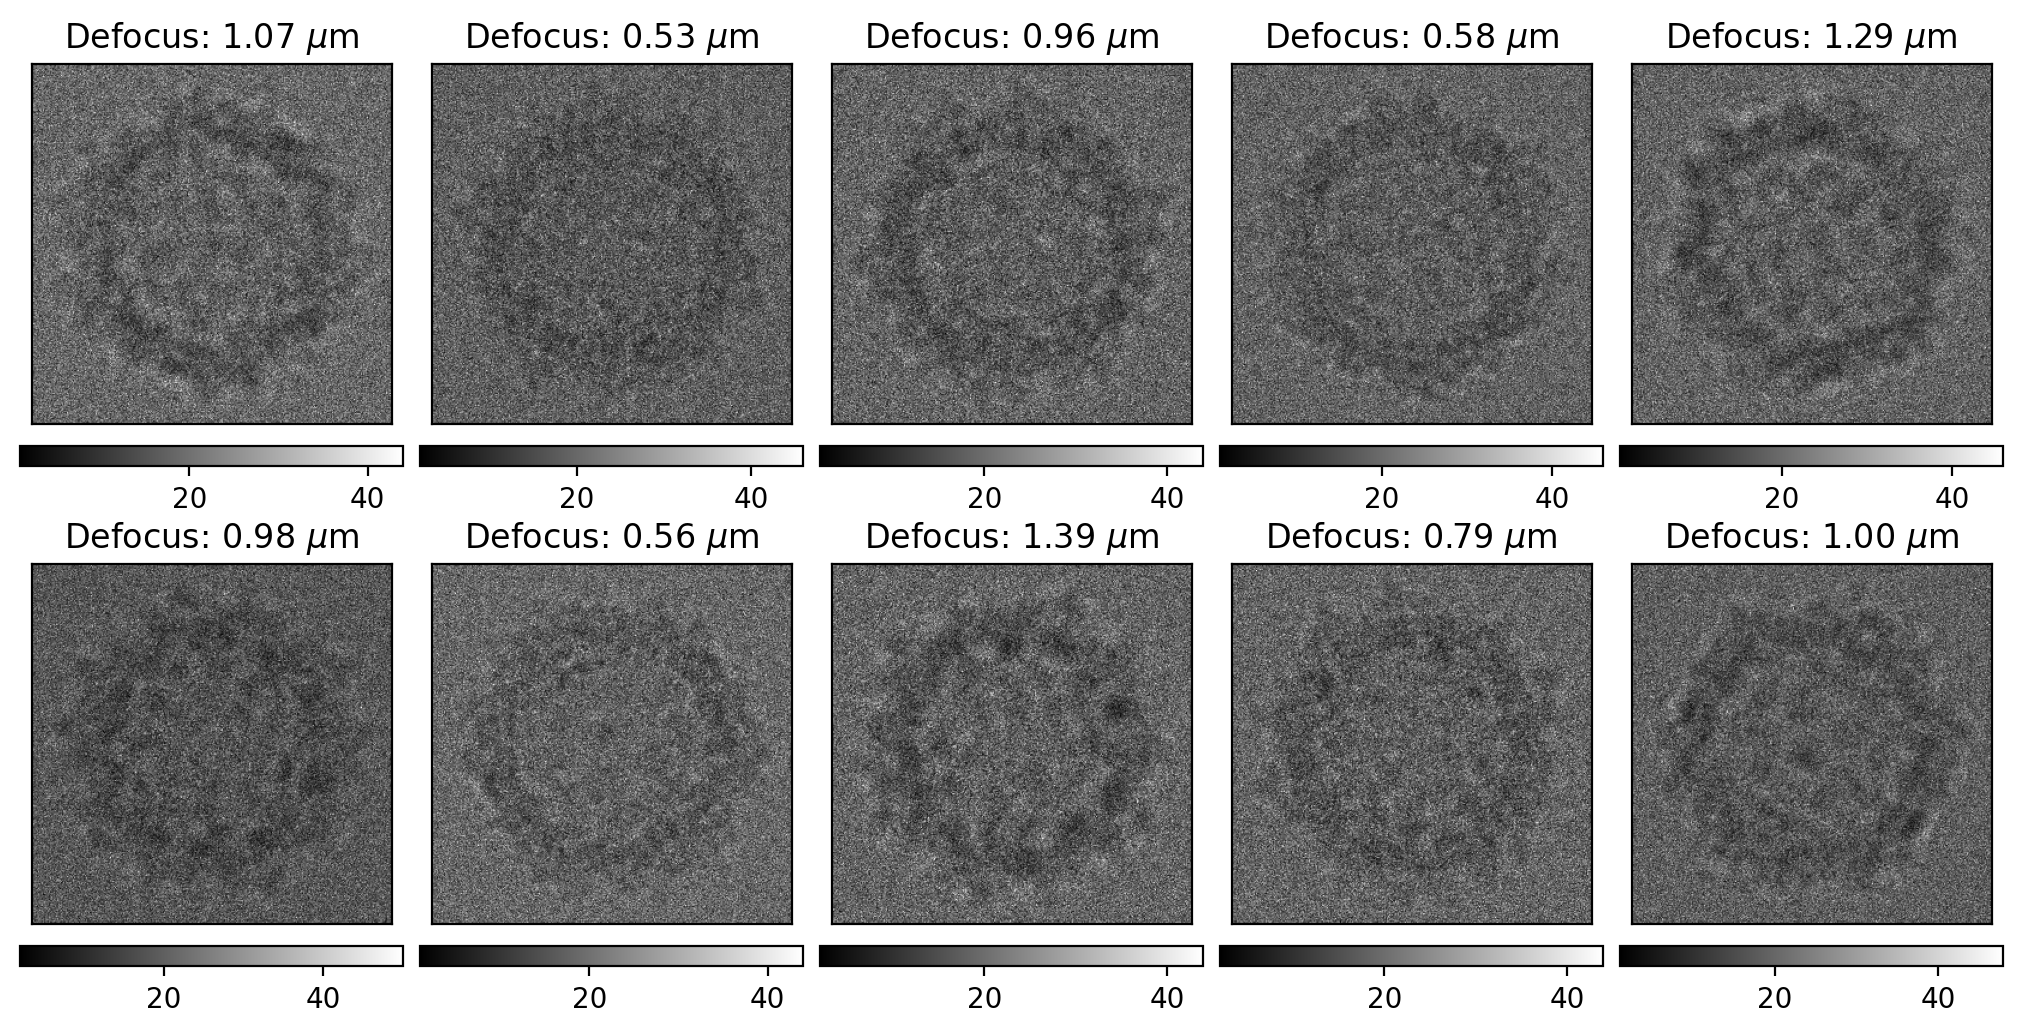

In [11]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

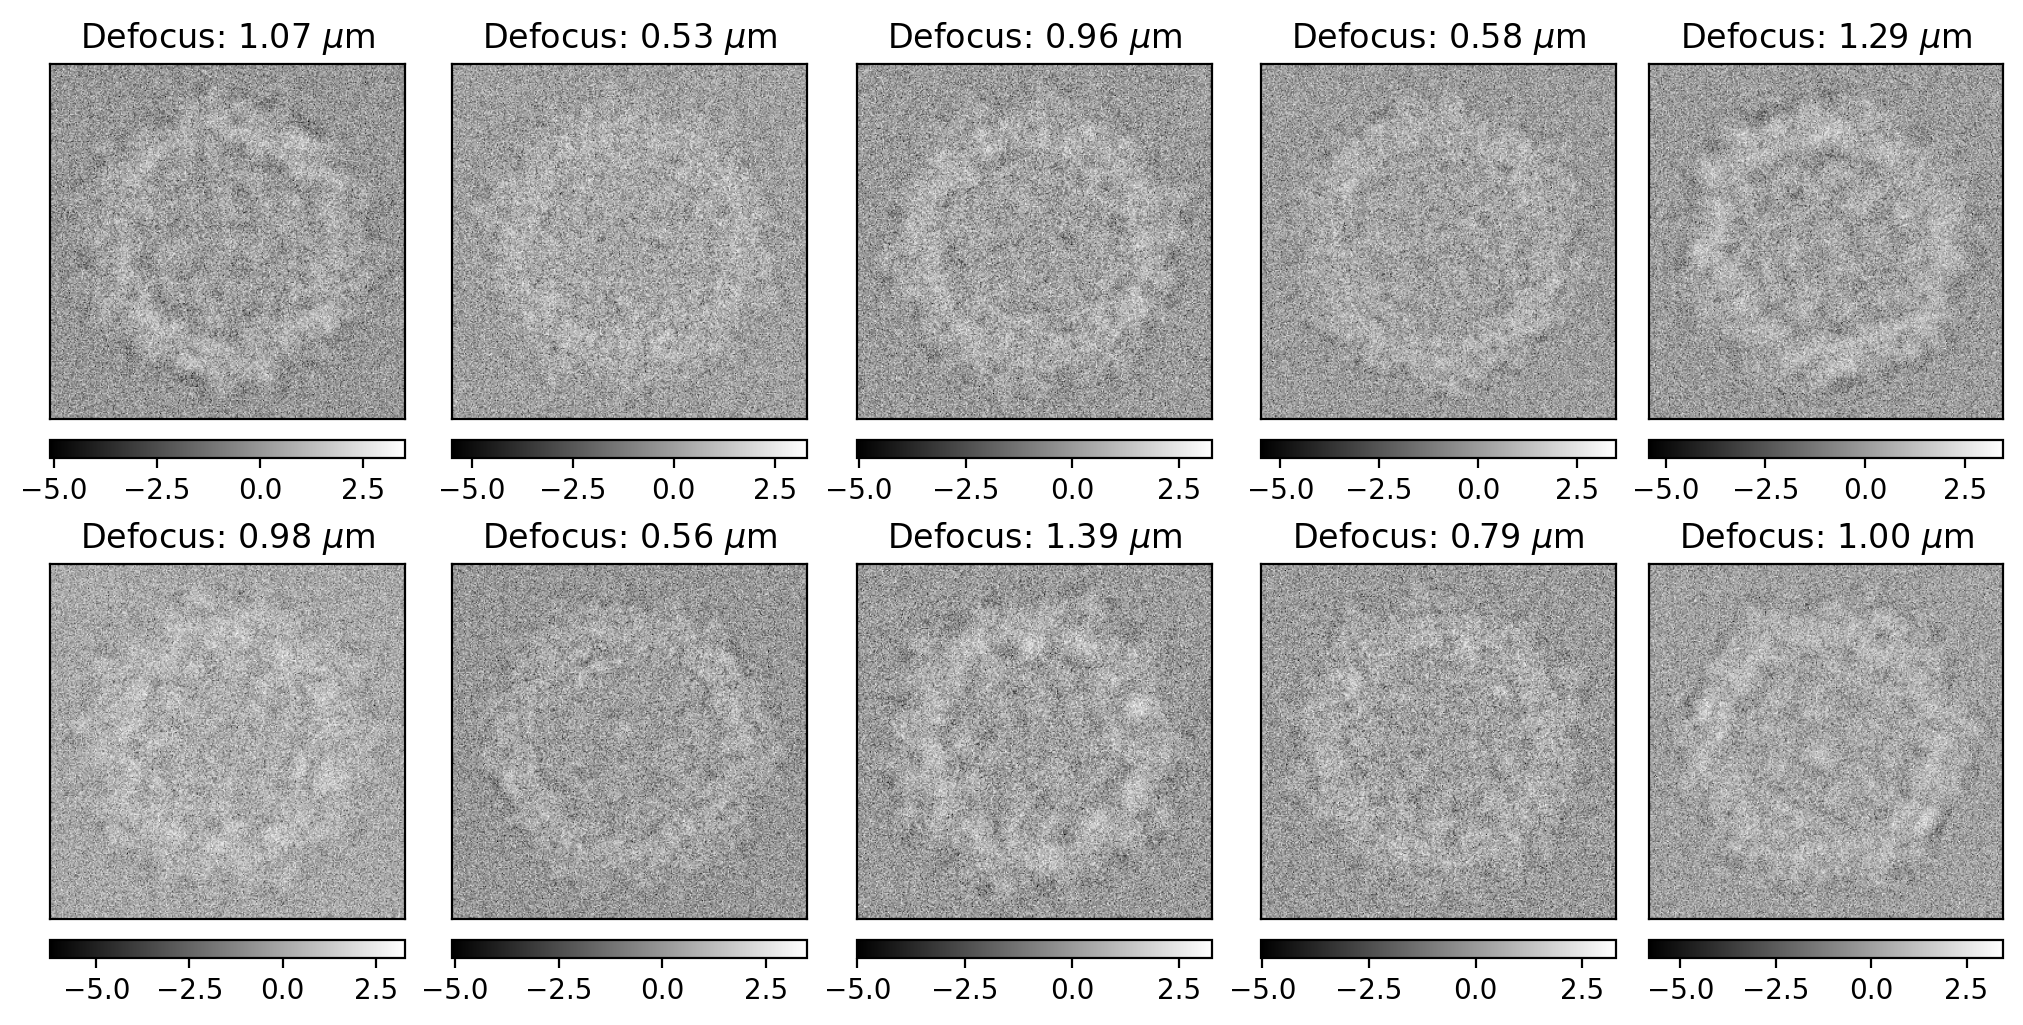

In [12]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()